In [3]:
#Emotion AI. Detectar los 30 puntos faciales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
from google.colab import drive
drive.mount('/content/drive')

keyfacial_df = pd.read_csv('/content/drive/MyDrive/Datasets/PIA/emotion.csv')

Mounted at /content/drive


In [5]:
keyfacial_df.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [6]:
keyfacial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [7]:
keyfacial_df.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


In [8]:
keyfacial_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


In [9]:
#Vale, lo que queremos en ver la primera imagen :-)

keyfacial_df['Image'][0]

'238 236 237 238 240 240 239 241 241 243 240 239 231 212 190 173 148 122 104 92 79 73 74 73 73 74 81 74 60 64 75 86 93 102 100 105 109 114 121 127 132 134 137 137 140 139 138 137 137 140 141 143 144 147 148 149 147 147 148 145 147 144 146 147 147 143 134 130 130 128 116 104 98 90 82 78 85 88 86 80 77 87 108 111 115 128 133 188 242 252 250 248 251 250 250 250 235 238 236 238 238 237 238 242 241 239 237 233 215 195 187 156 119 103 93 78 68 73 75 75 72 75 70 61 66 77 91 96 106 108 113 120 125 131 134 138 135 138 139 145 144 144 142 140 141 141 148 147 150 149 152 151 149 150 147 148 144 148 144 146 146 143 139 128 132 135 128 112 104 97 87 78 79 83 85 83 75 75 89 109 111 117 117 130 194 243 251 249 250 249 250 251 237 236 237 238 237 238 241 238 238 238 241 221 195 187 163 124 106 95 81 68 70 73 73 72 73 69 65 74 82 94 103 110 111 119 127 135 140 139 144 144 145 143 143 143 146 144 144 147 146 148 147 150 146 147 150 150 149 147 147 144 147 144 149 146 144 144 144 140 131 133 133 125 110 

In [10]:
def parse_image(img_str):
  return np.fromstring(img_str, dtype=int, sep=' ').reshape(96,96)

In [11]:
keyfacial_df['Image'] = keyfacial_df['Image'].apply(parse_image)

In [12]:

keyfacial_df['Image'][0].shape

(96, 96)

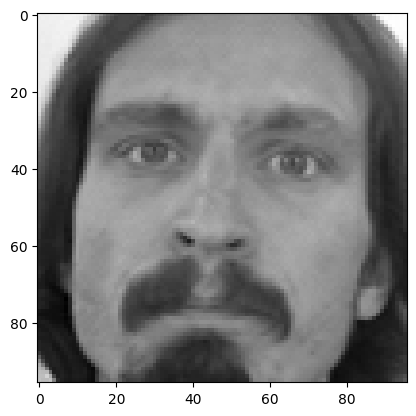

In [13]:
#Vamos a dibujar la primera imagen

plt.imshow(keyfacial_df['Image'][0], cmap='gray')

/tmp/ipython-input-264244970.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.iloc[i][j-1], keyfacial_df.iloc[i][j], 'rx')


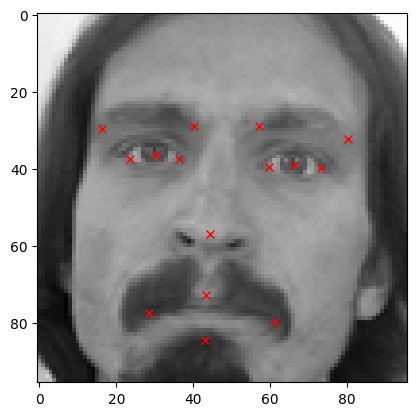

In [14]:
#vamos a dibujar los puntos claves
plt.imshow(keyfacial_df['Image'][0], cmap='gray')
i=0
for j in range (1,31,2):
  plt.plot(keyfacial_df.iloc[i][j-1], keyfacial_df.iloc[i][j], 'rx')

/tmp/ipython-input-4234156457.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.iloc[a][j-1], keyfacial_df.iloc[a][j], 'rx', markersize=5)


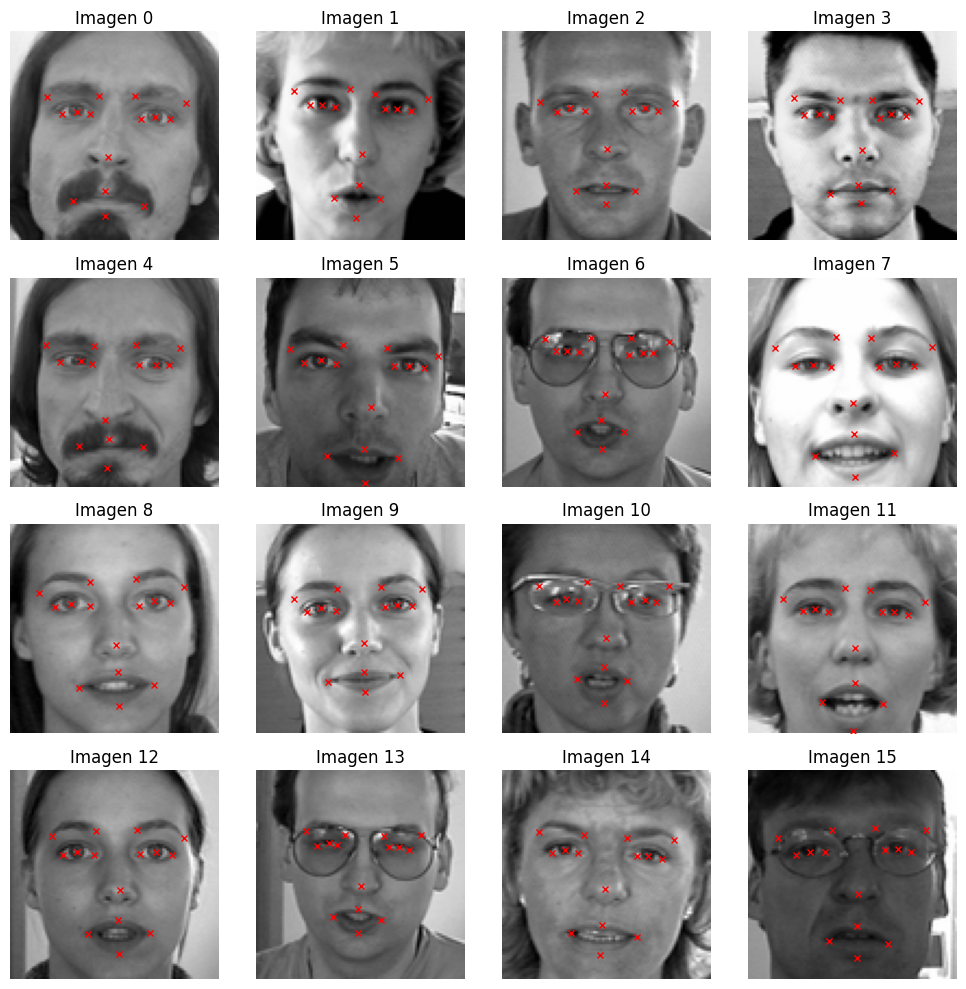

In [15]:
# Vamos a dibujar las 16 primeras imagenes

plt.figure(figsize=(10, 10))

for a in range(16):
    # El índice 'a + 1' es porque matplotlib empieza a contar subplots desde 1
    plt.subplot(4, 4, a + 1)

    plt.imshow(keyfacial_df['Image'][a], cmap='gray')

    for j in range(1, 31, 2):
        plt.plot(keyfacial_df.iloc[a][j-1], keyfacial_df.iloc[a][j], 'rx', markersize=5)

    plt.axis('off')
    plt.title(f"Imagen {a}")

plt.tight_layout() # Ajusta el espaciado entre imágenes
plt.show()



In [16]:
# Aumentación de las Imágenes

import copy

keyfacial_df_copy = copy.deepcopy(keyfacial_df)

In [17]:
def flip_image(img):
  return np.fliplr(img)

In [18]:
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(flip_image)

/tmp/ipython-input-3154611510.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.iloc[i][j-1], keyfacial_df.iloc[i][j], 'rx')


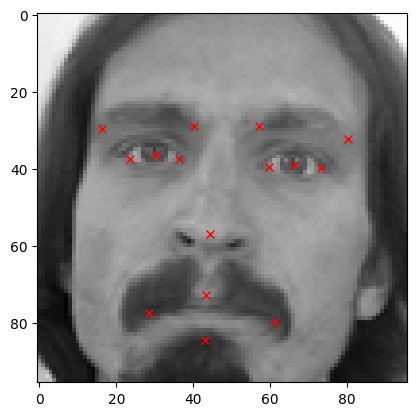

In [19]:
plt.imshow(keyfacial_df['Image'][0], cmap='gray')
i=0
for j in range (1,31,2):
  plt.plot(keyfacial_df.iloc[i][j-1], keyfacial_df.iloc[i][j], 'rx')

/tmp/ipython-input-2522422881.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.iloc[i][j-1], keyfacial_df_copy.iloc[i][j], 'rx')


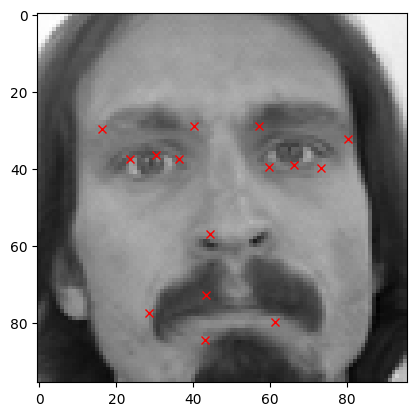

In [20]:
plt.imshow(keyfacial_df_copy['Image'][0], cmap='gray')
i=0
for j in range (1,31,2):
  plt.plot(keyfacial_df_copy.iloc[i][j-1], keyfacial_df_copy.iloc[i][j], 'rx')

In [21]:
# Vamos a hacer una función para cambiar las x

def flip_x(x):
  return 96 - float(x)

In [22]:
# Aplico columnas
columns = keyfacial_df_copy.columns[:-1]

for col in columns[::2]:
  keyfacial_df_copy[col] = keyfacial_df_copy[col].apply(flip_x)


/tmp/ipython-input-2522422881.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.iloc[i][j-1], keyfacial_df_copy.iloc[i][j], 'rx')


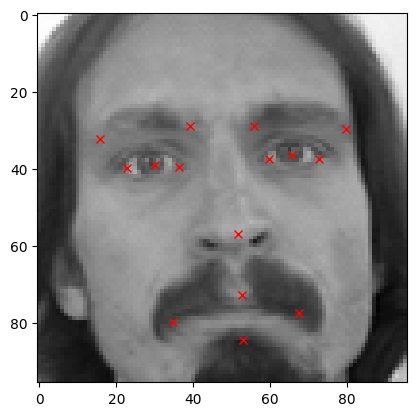

In [23]:
plt.imshow(keyfacial_df_copy['Image'][0], cmap='gray')
i=0
for j in range (1,31,2):
  plt.plot(keyfacial_df_copy.iloc[i][j-1], keyfacial_df_copy.iloc[i][j], 'rx')

In [24]:
# Vamos a concatenar

augmented_df = pd.concat([keyfacial_df, keyfacial_df_copy], ignore_index=True)

In [25]:
# Reto 2 : Hacer una copia augmented y voltearlas horizontalmente

keyfacial_df_copy2 = copy.deepcopy(augmented_df)

In [26]:
def flip_image_horizontal(img):
  return np.flip(img)

In [27]:
keyfacial_df_copy2['Image'] = keyfacial_df_copy2['Image'].apply(flip_image_horizontal)

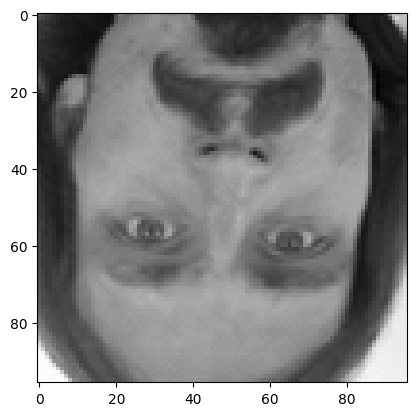

In [28]:
plt.imshow(keyfacial_df_copy2['Image'][0], cmap='gray')

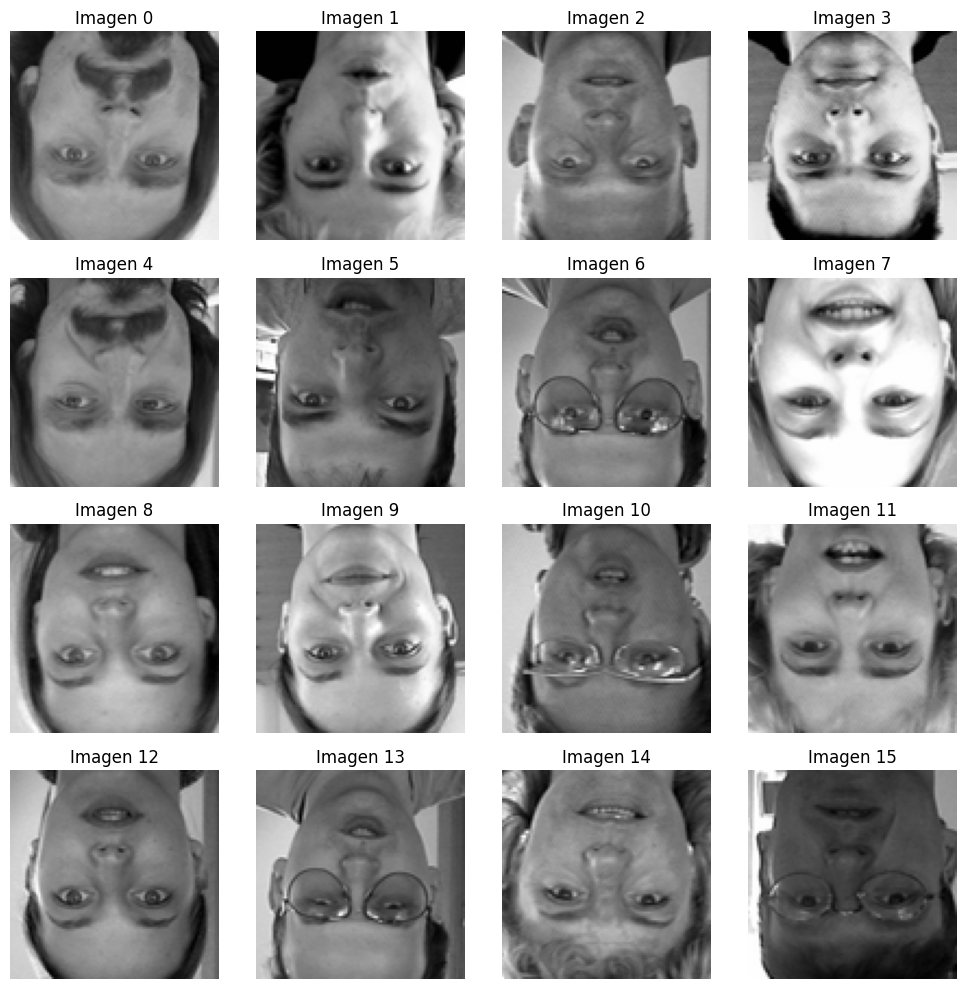

In [29]:
# Vamos a dibujar las 16 primeras imagenes

plt.figure(figsize=(10, 10))

for a in range(16):
    # El índice 'a + 1' es porque matplotlib empieza a contar subplots desde 1
    plt.subplot(4, 4, a + 1)

    plt.imshow(keyfacial_df_copy2['Image'][a], cmap='gray')

    plt.axis('off')
    plt.title(f"Imagen {a}")

plt.tight_layout() # Ajusta el espaciado entre imágenes
plt.show()


In [30]:
augmented_df = pd.concat([augmented_df, keyfacial_df_copy2], ignore_index=True)

In [31]:
# Vamos a aumentar el brillo de las imagenes, Para ellos se multiplica los píxeles por valores aleatorios entre 1,5 y 2

## OJO!! Que el valor tiene que estar entre 0 y 255

keyfacial_df_copy3 = copy.deepcopy(augmented_df)

In [32]:
def random_brighten(img):
    factor = np.random.uniform(1.5, 2)

    new_img = img * factor

    new_img = np.clip(new_img, 0, 255)

    return new_img.astype(np.uint8)

In [33]:
keyfacial_df_copy3['Image'] = keyfacial_df_copy3['Image'].apply(random_brighten)

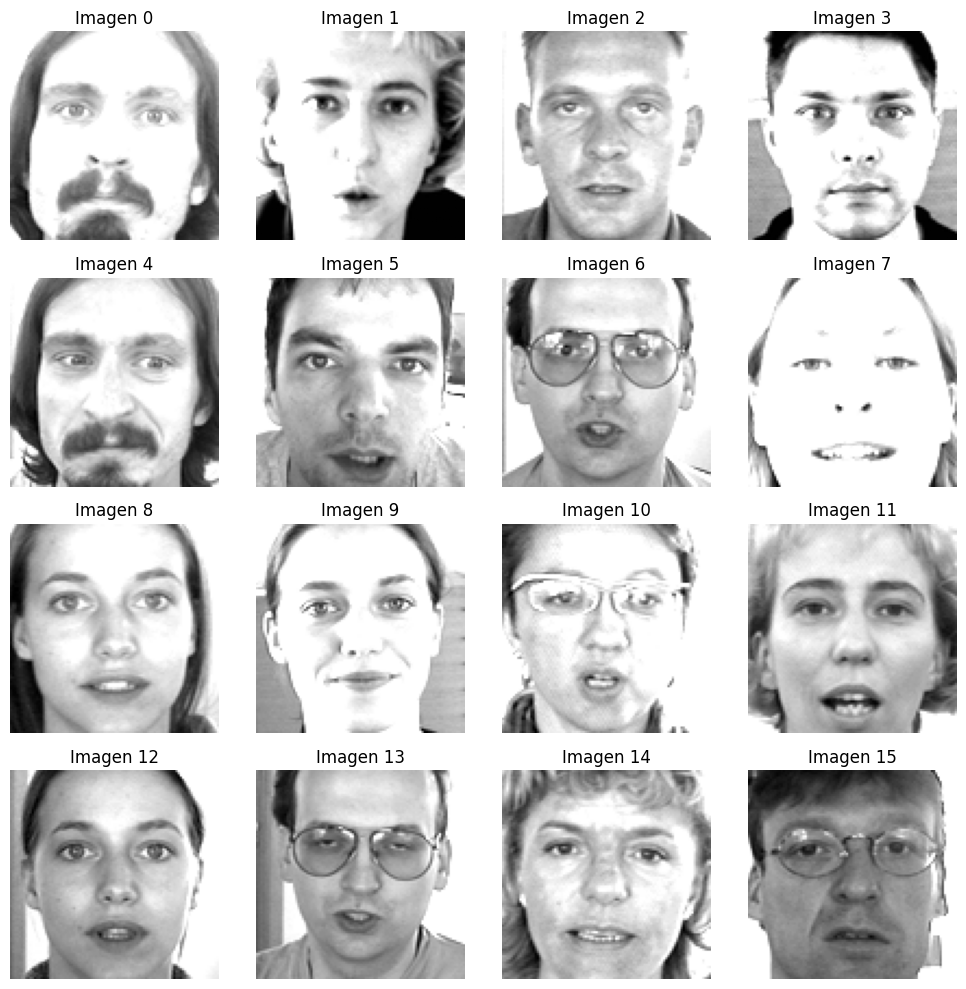

In [34]:
# Vamos a dibujar las 16 primeras imagenes

plt.figure(figsize=(10, 10))

for a in range(16):
    # El índice 'a + 1' es porque matplotlib empieza a contar subplots desde 1
    plt.subplot(4, 4, a + 1)

    plt.imshow(keyfacial_df_copy3['Image'][a], cmap='gray')

    plt.axis('off')
    plt.title(f"Imagen {a}")

plt.tight_layout() # Ajusta el espaciado entre imágenes
plt.show()

In [35]:
augmented_df = pd.concat([augmented_df, keyfacial_df_copy3], ignore_index=True)

In [36]:
from sklearn.model_selection import train_test_split

# --- A. Preparar las Imágenes (X) ---

# 1. Apilamos todas las imágenes en un solo array numpy
# Asumimos que las imágenes son 96x96 (típico en este dataset), ajusta si es diferente.
img_size = 96
X = np.stack(augmented_df['Image'].values)

# 2. Normalizar: Pasamos de 0-255 a 0-1
X = X / 255.0

# 3. Reshape: Keras necesita (Batch, Alto, Ancho, Canales)
# El -1 indica "toda la cantidad de fotos que haya"
X = X.reshape(-1, img_size, img_size, 1)

# --- B. Preparar los Puntos Clave / Objetivos (y) ---

# Seleccionamos todas las columnas excepto la imagen (las coordenadas x, y)
# Asegúrate de rellenar nulos antes si no lo has hecho (fillna)
y = augmented_df.drop('Image', axis=1).values

# --- C. Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (13696, 96, 96, 1)
Forma de y_train: (13696, 30)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# --- Capa Convolucional 1 ---
# Filtros: 32, Kernel: 3x3, Activación: Relu
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)))
model.add(MaxPooling2D((2, 2)))

# --- Capa Convolucional 2 ---
# Aumentamos filtros a 64 para capturar detalles más complejos
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# --- Capa Convolucional 3 (Opcional, para mayor profundidad) ---
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# --- Aplanar y Densas ---
model.add(Flatten())

# Capa oculta densa
model.add(Dense(128, activation='relu'))

# Dropout para evitar overfitting (apaga el 30% de neuronas aleatoriamente)
model.add(Dropout(0.3))

# --- CAPA DE SALIDA ---
# IMPORTANTE: El número de neuronas = número de columnas en 'y' (30 si son 15 puntos x,y)
# No usamos activación (o usamos 'linear') porque queremos predecir coordenadas exactas, no probabilidades.
model.add(Dense(y_train.shape[1]))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,070 (6.62 MB)

 Trainable params: 1,735,070 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# 1. Compilar
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# MAE (Mean Absolute Error) nos dice cuántos píxeles nos equivocamos en promedio

# 2. Entrenar
history = model.fit(
    X_train, y_train,
    epochs=15,             # Número de vueltas
    batch_size=32,         # Imágenes procesadas a la vez
    validation_data=(X_test, y_test) # Comprobar qué tal va con datos nuevos
)

Epoch 1/15
428/428 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 638.4160 - mae: 18.9204 - val_loss: 175.2665 - val_mae: 9.1071
Epoch 2/15
102/428 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 237.0336 - mae: 11.5830

KeyboardInterrupt: 

# PRÁCTICA: IMPLEMENTACIÓN DE RESNET


## PARTE 1: Comprensión Teórica

### 1.1 Analiza los Diagramas

1. ¿Qué es un Bloque RES?

Es la unidad fundamental de una ResNet. Consiste en unas pocas capas convolucionales (generalmente 2 o 3) donde la entrada original se suma a la salida final del bloque. Esto permite entrenar redes mucho más profundas evitando el problema del desvanecimiento del gradiente (vanishing gradient).

2. ¿Cuál es la diferencia entre un "Bloque de Convolución" y un "Bloque de Identidad"?

Bloque de Identidad: La entrada $X$ y la salida de las convoluciones tienen las mismas dimensiones. La conexión residual se suma directamente.

Bloque de Convolución: Las dimensiones cambian (normalmente se reducen a la mitad por el stride o cambia el número de filtros). Aquí, el "camino corto" también necesita pasar por una pequeña convolución (generalmente $1 \times 1$) para igualar las dimensiones antes de sumarse.

3. ¿Qué función cumple el "Camino Corto" (skip connection)?

Permite que el gradiente fluya directamente hacia atrás a través de la red durante el backpropagation, saltándose capas no lineales. Esto facilita que la red aprenda la función identidad si las capas adicionales no son necesarias.

4. ¿En qué casos se aplica una convolución en el camino corto?

Cuando las dimensiones espaciales ($Height \times Width$) o la profundidad (canales/filtros) de la entrada no coinciden con la salida del bloque principal (por ejemplo, cuando usamos strides=2).

## PARTE 2: Implementación del Bloque Residual

### 2.1 Importar Librerías

In [39]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout, ZeroPadding2D
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
import os

### 2.2 Implementar la Función res_block

In [40]:
def res_block(X, filter, stage, s=1):
    """
    Implementa un stage completo de ResNet que consiste en:
    1 Bloque Convolucional (para downsampling o cambio de filtros)
    2 Bloques de Identidad

    Argumentos:
    X -- tensor de entrada
    filter -- lista [f1, f2, f3] con número de filtros
    stage -- número del stage (para nombrar capas)
    s -- stride (1 para identidad, 2 para downsampling)
    """

    # -----------------------------------------------------------
    # BLOQUE 1: BLOQUE CONVOLUCIONAL (El único que usa stride 's')
    # -----------------------------------------------------------
    X_copy = X
    f1, f2, f3 = filter

    # --- Camino Principal ---
    # 1. Primera componente (Convolución 1x1)
    X = Conv2D(f1, (1,1), strides=(s,s), name='res_'+str(stage)+'_conv_a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_conv_a')(X)
    X = Activation('relu')(X)

    # 2. Segunda componente (Convolución 3x3)
    X = Conv2D(f2, kernel_size=(3,3), strides=(1,1), padding='same', name='res_'+str(stage)+'_conv_b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_conv_b')(X)
    X = Activation('relu')(X)

    # 3. Tercera componente (Convolución 1x1)
    X = Conv2D(f3, kernel_size=(1,1), strides=(1,1), name='res_'+str(stage)+'_conv_c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_conv_c')(X)

    # --- Camino Corto (Shortcut Path) ---
    # Se aplica convolución si hay stride > 1 o si los canales no coinciden
    if s > 1 or K.int_shape(X_copy)[-1] != f3:
        X_copy = Conv2D(f3, kernel_size=(1,1), strides=(s,s), name='res_'+str(stage)+'_0_conv_copy', kernel_initializer=glorot_uniform(seed=0))(X_copy)
        X_copy = BatchNormalization(axis=3, name='bn_'+str(stage)+'_0_conv_copy')(X_copy)

    # --- Unión ---
    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    # -----------------------------------------------------------
    # BLOQUE 2: BLOQUE DE IDENTIDAD 1
    # -----------------------------------------------------------
    X_copy = X

    # 1. Conv 1x1
    X = Conv2D(f1, (1,1), strides=(1,1), name='res_'+str(stage)+'_identity_1_a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_1_a')(X)
    X = Activation('relu')(X)

    # 2. Conv 3x3 (padding same)
    X = Conv2D(f2, kernel_size=(3,3), strides=(1,1), padding='same', name='res_'+str(stage)+'_identity_1_b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_1_b')(X)
    X = Activation('relu')(X)

    # 3. Conv 1x1
    X = Conv2D(f3, kernel_size=(1,1), strides=(1,1), name='res_'+str(stage)+'_identity_1_c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_1_c')(X)

    # Unión (Directa, sin conv en shortcut)
    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    # -----------------------------------------------------------
    # BLOQUE 3: BLOQUE DE IDENTIDAD 2
    # -----------------------------------------------------------
    X_copy = X

    # 1. Conv 1x1
    X = Conv2D(f1, (1,1), strides=(1,1), name='res_'+str(stage)+'_identity_2_a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_2_a')(X)
    X = Activation('relu')(X)

    # 2. Conv 3x3
    X = Conv2D(f2, kernel_size=(3,3), strides=(1,1), padding='same', name='res_'+str(stage)+'_identity_2_b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_2_b')(X)
    X = Activation('relu')(X)

    # 3. Conv 1x1
    X = Conv2D(f3, kernel_size=(1,1), strides=(1,1), name='res_'+str(stage)+'_identity_2_c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_'+str(stage)+'_identity_2_c')(X)

    # Unión
    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    return X

## PARTE 3: Construcción del Modelo Completo

### 3.1 Diseña la Arquitectura Completa

In [41]:
def create_resnet_model(input_shape=(96, 96, 1), num_outputs=30):
    """
    Crea el modelo ResNet completo adaptado para detección de puntos faciales (regresión)
    """

    # Definir tensor de entrada
    X_input = Input(input_shape)

    # 1. Zero-Padding Inicial
    X = ZeroPadding2D((3,3))(X_input)

    # 2. Fase 1: Convolución Inicial + MaxPool
    X = Conv2D(64, (7,7), strides=(2,2), name='conv1', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3,3), strides=(2,2))(X)

    # 3. Fase 2: Bloque Residual (Stage 2)
    # Filtros: [64, 64, 256], Stride 1 (sin reducción espacial inicial)
    X = res_block(X, filter=[64, 64, 256], stage=2, s=1)

    # 4. Fase 3: Bloque Residual (Stage 3)
    # Filtros: [128, 128, 512], Stride 2 (reducción espacial a la mitad)
    X = res_block(X, filter=[128, 128, 512], stage=3, s=2)

    # 5. Capas Finales (Clasificación/Regresión)
    X = AveragePooling2D((2,2), name='Average_Pooling')(X)
    X = Flatten()(X)

    # Dense Layers (Fully Connected)
    X = Dense(4096, activation='relu')(X)
    X = Dropout(0.2)(X)
    X = Dense(2048, activation='relu')(X)
    X = Dropout(0.1)(X)

    # Capa de salida: 30 neuronas (coordenadas x,y para 15 puntos clave)
    X = Dense(num_outputs, activation='relu')(X) # Nota: Usar 'relu' en salida asume coordenadas positivas

    # Crear el modelo
    model = Model(inputs=X_input, outputs=X, name='ResNet_FacialKeyPoints')

    return model

## PARTE 4: Verificación y Pruebas

### 4.1 Crea y Visualiza el Modelo

In [42]:
# Instanciar el modelo
model_1_facialKeyPoints = create_resnet_model(input_shape=(96, 96, 1), num_outputs=30)

# Ver resumen de arquitectura
model_1_facialKeyPoints.summary()

Model: "ResNet_FacialKeyPoints"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 23, 23,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_3[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 23, 23,    │        256 │ res_2_conv_a[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 23, 23,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 23, 23,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 23, 23,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 23, 23,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 23, 23,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_0_conv_copy   │ (None, 23, 23,    │     16,640 │ max_pooling2d_3[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 23, 23,    │      1,024 │ res_2_conv_c[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_0_conv_copy    │ (None, 23, 23,    │      1,024 │ res_2_0_conv_cop… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 23,    │          0 │ bn_2_conv_c[0][0

 Total params: 85,125,150 (324.73 MB)

 Trainable params: 85,116,574 (324.69 MB)

 Non-trainable params: 8,576 (33.50 KB)

### 4.2 Verifica los Parámetros (Respuestas esperadas)

5. ¿Cuántos parámetros entrenables tiene tu modelo?

6. ¿Cuál es la forma del tensor después de cada fase?


7. ¿Por qué hay bloques de identidad después del bloque convolucional?


### 4.3 Compila el Modelo

In [43]:
# Definir Optimizador
adam = tf.keras.optimizers.Adam(learning_rate = 0.0001, beta_1 = 0.9, beta_2 = 0.999, amsgrad = False)

# Compilar
model_1_facialKeyPoints.compile(loss = "mean_squared_error", optimizer = adam , metrics = ['mae'])

# --- CORRECCIÓN AQUÍ ---
# Configurar Checkpoint para guardar el mejor modelo
# Cambiamos .hdf5 por .keras
checkpointer = ModelCheckpoint(filepath = "FacialKeyPoints_weights.keras",
                               verbose = 1,
                               save_best_only = True)

# Guardar arquitectura a JSON
model_json = model_1_facialKeyPoints.to_json()
with open("FacialKeyPoints-model.json","w") as json_file:
    json_file.write(model_json)

print("Modelo compilado y arquitectura guardada.")

Modelo compilado y arquitectura guardada.


In [ ]:
history = model_1_facialKeyPoints.fit(X_train, y_train, batch_size = 32, epochs = 10, validation_split = 0.05, callbacks=[checkpointer])

## PARTE 5: Preguntas de Reflexión

8. Ventajas de ResNet: ¿Por qué las skip connections ayudan al entrenamiento de redes profundas?

Ayudan a mitigar el problema del Vanishing Gradient. Al permitir que el gradiente fluya por el camino corto, las capas profundas pueden aprender al menos la función identidad, garantizando que añadir más capas no empeore el rendimiento del modelo (degradación), lo cual permite redes mucho más profundas (ResNet50, ResNet101).

9. Bottleneck Design: ¿Por qué se usan convoluciones 1x1 antes y después de la convolución 3x3?

Se usa para eficiencia computacional.La primera $1 \times 1$ reduce la profundidad (número de canales) antes de la operación costosa de $3 \times 3$.La última $1 \times 1$ restaura la profundidad original.Esto se conoce como estructura de "cuello de botella" (bottleneck) y ahorra parámetros y cálculo.

10. Batch Normalization: ¿Qué papel juega en cada bloque residual?

Normaliza la salida de la capa anterior (media 0, varianza 1) antes de la función de activación. Esto estabiliza el aprendizaje, permite tasas de aprendizaje (learning rates) más altas y actúa como una ligera regularización.

11. Downsampling: ¿En qué momentos se reduce el tamaño espacial de los feature maps?

En la primera Convolución ($7 \times 7$, stride 2).En el MaxPooling inicial.En el primer bloque del Stage 3 (debido al stride $s=2$).En el AveragePooling final.

12. Aplicaciones: ¿Qué cambios harías para usar este modelo en clasificación de emociones (7 clases) en lugar de detección de keypoints?

Salida: Cambiar la última capa Dense(30, activation='relu') por Dense(7, activation='softmax').

Compilación: Cambiar la función de pérdida de mean_squared_error a categorical_crossentropy (o sparse_categorical_crossentropy).

Métrica: Usar accuracy en lugar de mae.

In [44]:
# Cargar la arquitectura del modelo guardada en formato JSON
with open('detection.json', 'r') as json_file:
    json_savedModel = json_file.read()

In [45]:
# Reconstruir el modelo a partir del JSON (incluyendo objetos personalizados)
model_1_facialKeyPoints = tf.keras.models.model_from_json(
    json_savedModel,
    custom_objects={'Model': tf.keras.Model}
)

In [46]:
# Cargar los pesos entrenados del modelo
model_1_facialKeyPoints.load_weights('weights_keypoint.hdf5')

# Definir el optimizador Adam con una tasa de aprendizaje baja
adam = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.9,
    beta_2=0.999,
    amsgrad=False
)

# Compilar el modelo especificando la función de pérdida y la métrica
# MSE se usa porque es un problema de regresión (predicción de coordenadas)
model_1_facialKeyPoints.compile(
    loss="mean_squared_error",
    optimizer=adam,
    metrics=['mae']
)

In [47]:
# ---------------- ENTRENAMIENTO DEL MODELO ----------------
history = model_1_facialKeyPoints.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - loss: 97.6701 - mae: 5.6271 - val_loss: 58.2973 - val_mae: 3.7836
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 39.8851 - mae: 3.3007 - val_loss: 45.3813 - val_mae: 3.1778
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 22.0750 - mae: 2.6160 - val_loss: 44.3859 - val_mae: 2.9230
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 15.3870 - mae: 2.2453 - val_loss: 42.3189 - val_mae: 2.7055
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 10.5121 - mae: 2.0042 - val_loss: 44.1564 - val_mae: 2.9429
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 9.9849 - mae: 1.9832 - val_loss: 47.5965 - val_mae: 2.8393
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 10.2281 - mae: 1.9823 - val_loss: 46.9900 - val_mae: 2.7378
Epoch 8/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 9.6940 - mae: 1.9184 - val_loss: 41.9679 - val_mae: 2.6906
Epoch 9/50
343/343 ━━━━━━━━━━━━━

In [48]:
# Evaluar el modelo sobre el conjunto de test para obtener loss y MAE
model_1_facialKeyPoints.evaluate(X_test, y_test)

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 35.9063 - mae: 2.1078


[34.57625961303711, 2.042041540145874]

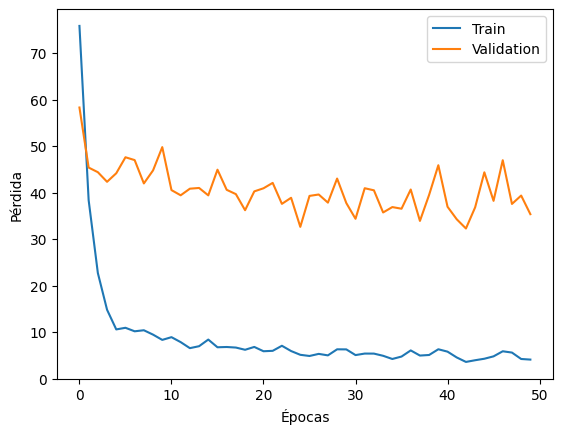

In [49]:
# Representar gráficamente la evolución del loss y val_loss durante el entrenamiento
# (requiere el objeto history obtenido con model.fit)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(['Train', 'Validation'])
plt.show()
